## Cell 1: Imports & Setup

In [ ]:
import random
import os
import copy
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Union
from dotenv import load_dotenv
load_dotenv()
import matplotlib.pyplot as plt
import json
import time
import google.generativeai as genai
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns

# Mount Drive

# API Key (Ensure this is set in Colab Secrets)


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


## Cell 2: Configurations

In [ ]:
@dataclass
class ExperimentConfig:
    # --- Model & Device ---
    model_name: str = "meta-llama/Llama-3.1-8B-Instruct"
    device_map: str = "auto"
    torch_dtype: torch.dtype = torch.bfloat16
    base_dir: str = "results_v1"

    # --- Input Data ---
    # Path to your CSV file
    csv_file: str = "results_v1/Entities_QA.csv"
    # Train or Test
    mode: str = "train"

    # --- Extraction (Input to Adapter) ---
    extraction_layer: int = 16
    extraction_pos: str = "resid_post"
    normalize_vectors: bool = True

    # --- Injection (Output of Adapter) ---
    injection_layer: int = 16

    # --- Training Settings ---
    architecture_id: int = 1
    train_ratio: float = 0.8
    adapter_lr: float = 1e-3
    adapter_epochs: int = 15
    adapter_hidden_dim: int = 4096
    batch_size: int = 8          # Reduced batch size as full sentences take more VRAM
    seed: int = 42
    dropout: float = 0.0

    use_lowercase: bool = True

    # --- Extraction Prompting (For getting the concept vector) ---
    prompt_id: int = 1
    concept_chat_template: List[Dict] = field(default_factory=lambda: [
        {"role": "user", "content": "Tell me about {word}"}
    ])

    # Placeholder for the words list (populated dynamically from CSV)
    words: List[str] = field(default_factory=list)
    concept_prefix: Optional[str] = None

    def get_safe_model_name(self):
        return self.model_name.replace("/", "_")

    @property
    def cache_dir(self):
        path = os.path.join(self.base_dir, "learning_cache")
        os.makedirs(path, exist_ok=True)
        return path

    @property
    def adapter_save_path(self):
        path = os.path.join(self.base_dir, "trained_adapters")
        os.makedirs(path, exist_ok=True)
        fname = f"adapter_{self.get_safe_model_name()}_L{self.injection_layer}_architecture{self.architecture_id}_hollistic.pt"
        return os.path.join(path, fname)

## Cell 3: Helpers & Concept Extraction

In [ ]:
@torch.inference_mode()
def get_layer_activation(
    model, tokenizer, prompt, layer_idx: int, which: str = "resid_post",
    token_pos: str | int = "last"
):
    # Validate layer bounds
    n_layers = getattr(model.config, "num_hidden_layers", None)
    if n_layers is not None:
        assert 0 <= layer_idx < n_layers, f"layer_idx out of range"

    if getattr(tokenizer, "padding_side", None) is not None:
        tokenizer.padding_side = "right" # Important for extraction

    dev = model.device
    batch_texts = prompt if isinstance(prompt, list) else [prompt]

    enc = tokenizer(
        batch_texts, return_tensors="pt", padding=True, truncation=True, add_special_tokens=True
    )
    enc = {k: v.to(dev) for k, v in enc.items()}

    out = model(**enc, output_hidden_states=True, use_cache=False)
    hs = out.hidden_states

    if which == "resid_pre":
        acts = hs[layer_idx]
    elif which == "resid_post":
        acts = hs[layer_idx + 1]
    else:
        raise ValueError('which must be "resid_pre" or "resid_post"')

    B, T, H = acts.shape
    if token_pos == "last":
        lengths = enc["attention_mask"].sum(dim=1) - 1
        lengths = lengths.clamp(min=0)
        batch_ix = torch.arange(B, device=acts.device)
        picked = acts[batch_ix, lengths]
        return picked.detach().to("cpu")

    raise ValueError('For extraction, only token_pos="last" is implemented here')


def make_chat_prompt(tokenizer, template_messages: List[Dict], word: str) -> str:
    messages = copy.deepcopy(template_messages)
    for msg in messages:
        if "{word}" in msg["content"]:
            msg["content"] = msg["content"].format(word=word)
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def get_concept_vectors(cfg: ExperimentConfig, model, tokenizer):
    """
    Extracts vectors for the unique words found in the CSV.
    """
    if not cfg.words:
        print("Warning: Config word list is empty. Load CSV first.")
        return {}

    norm_tag = "norm" if cfg.normalize_vectors else "raw"
    case_tag = "lower" if cfg.use_lowercase else "orig"

    # We use a hash or length of words list to ensure filename uniqueness if data changes
    filename = (
        f"{cfg.mode}_concepts_{cfg.get_safe_model_name()}_"
        f"L{cfg.extraction_layer}_{cfg.extraction_pos}_"
        f"{norm_tag}_{case_tag}.pt"
    )
    filepath = os.path.join(cfg.cache_dir, filename)

    if os.path.exists(filepath):
        print(f"Loading concept bank from: {filepath}")
        data = torch.load(filepath, map_location="cpu")
        return data["vectors"]

    print(f"Computing concept vectors for {len(cfg.words)} words...")
    concept_vecs = {}

    # Ensure unique words only for extraction to save time
    unique_words = list(set(cfg.words))

    for w_original in tqdm(unique_words, desc="Concept Vectors"):
        w_for_key = w_original.lower() if cfg.use_lowercase else w_original
        prompt = make_chat_prompt(tokenizer, cfg.concept_chat_template, w_original)

        act = get_layer_activation(
            model, tokenizer, prompt,
            layer_idx=cfg.extraction_layer,
            which=cfg.extraction_pos,
            token_pos="last"
        )
        vec = act.float()

        if cfg.normalize_vectors:
            norm = vec.norm()
            if norm > 1e-6:
                vec = vec / norm

        concept_vecs[w_for_key] = vec

    torch.save({"words": list(concept_vecs.keys()), "vectors": concept_vecs}, filepath)
    print(f"Saved concept bank to: {filepath}")
    return concept_vecs

## Cell 4: Adapter Model

#### ID 1

In [ ]:
# class InjectionAdapter(torch.nn.Module):
#     def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float = 0.0):
#         super().__init__()
#         # FC -> ReLU -> Dropout -> FC
#         self.model = torch.nn.Sequential(
#             torch.nn.Linear(input_dim, hidden_dim),
#             torch.nn.ReLU(),
#             torch.nn.Dropout(dropout_prob),
#             torch.nn.Linear(hidden_dim, input_dim)
#         )
#         # Zero Initialization: Start with no intervention
#         with torch.no_grad():
#             self.model[-1].weight.zero_()
#             self.model[-1].bias.zero_()

#     def forward(self, x):
#         return self.model(x)

#### ID 2

In [ ]:
class InjectionAdapter(torch.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float):
        super().__init__()
        # inpout -> hidden -> hidden // 2 -> hidden -> input
        self.model = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout_prob),
            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout_prob),
            torch.nn.Linear(hidden_dim // 2, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout_prob),
            torch.nn.Linear(hidden_dim, input_dim)
        )
        # Zero Initialization: Start with no intervention
        with torch.no_grad():
            self.model[-1].weight.zero_()
            self.model[-1].bias.zero_()

    def forward(self, x):
        return self.model(x)

## Cell 5: Data Processing (CSV Handling)

In [ ]:
def process_data(cfg: ExperimentConfig, tokenizer):
    print(f"--- Loading Data from {cfg.csv_file} ---")

    # 1. Load CSV
    # Ensure the path is correct. If running locally, file must exist.
    if not os.path.exists(cfg.csv_file):
        raise FileNotFoundError(f"Could not find {cfg.csv_file}. Please upload it.")

    df = pd.read_csv(cfg.csv_file)

    # Check columns
    required_cols = ['Category', 'Entity', 'Question', 'Answer']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"CSV must contain columns: {required_cols}")

    valid_data = []
    unique_words = set()

    print("Processing rows...")
    for idx, row in df.iterrows():
        category = str(row['Category'])
        entity = str(row['Entity'])
        question = str(row['Question'])
        answer = str(row['Answer'])

        # Apply casing policy to the concept word and category for keying
        entity_key = entity.lower() if cfg.use_lowercase else entity
        category_key = category.lower() if cfg.use_lowercase else category

        unique_words.add(entity) # Keep original casing for extraction prompt

        valid_data.append({
            "category_key": category_key, # Key to look up vector if needed
            "entity_key": entity_key,   # Key to look up vector
            "entity_original": entity,      # For reference
            "question": question,
            "answer": answer
        })

    # Update Config with the list of unique words needed for extraction
    cfg.words = list(unique_words)
    print(f"Found {len(cfg.words)} unique entities across {len(valid_data)} training examples.")

    # 2. Stratified Split based on ('Category', 'Entity') combination
    random.seed(cfg.seed)
    train_data = []
    val_data = []

    # Group by the combination of category_key and entity_key
    grouped_data = {}
    for item in valid_data:
        key = (item['category_key'], item['entity_key'])
        if key not in grouped_data:
            grouped_data[key] = []
        grouped_data[key].append(item)

    for key, examples in grouped_data.items():
        if len(examples) > 0:
            # Randomly select one example for the test set
            test_example = random.choice(examples)
            val_data.append(test_example)
            # Add the rest to the training set
            train_data.extend([e for e in examples if e != test_example])

    print(f"Split: {len(train_data)} Train / {len(val_data)} Validation")
    return train_data, val_data

## Cell 6: Training Loop (Holistic Loss)

In [ ]:
def train_adapter(cfg: ExperimentConfig, model, tokenizer, adapter, train_data, test_data, concept_vecs):

    optimizer = torch.optim.AdamW(adapter.parameters(), lr=cfg.adapter_lr)
    loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100) # Ignore masked tokens

    adapter = adapter.to(model.device, dtype=cfg.torch_dtype)
    adapter.train()

    print(f"Starting training for {cfg.adapter_epochs} epochs...")
    history = []

    # Prepare standard chat formatting
    # We need to manually construct [Prompt] + [Answer]

    for epoch in range(cfg.adapter_epochs):
        total_loss = 0
        random.shuffle(train_data)

        pbar = tqdm(range(0, len(train_data), cfg.batch_size), desc=f"Epoch {epoch+1}")

        for i in pbar:
            batch = train_data[i : i + cfg.batch_size]

            # --- 1. Prepare Inputs & Labels ---
            input_ids_list = []
            labels_list = []
            injection_indices = []
            batch_vectors = []

            for item in batch:
                # Get Entity Vector
                vec = concept_vecs.get(item['entity_key'])
                if vec is None: continue # Should not happen
                batch_vectors.append(vec)

                # Format Prompt: User Question
                msgs = [{"role": "user", "content": item['question']}]
                prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

                # Format Target: The Answer (We add a space usually for continuation)
                answer_str = item['answer'] + tokenizer.eos_token

                # Tokenize separately to know lengths
                prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
                answer_ids = tokenizer.encode(answer_str, add_special_tokens=False)

                # Concatenate
                full_ids = prompt_ids + answer_ids

                # Create Labels: -100 for prompt (don't train), actual IDs for answer
                # We do -100 for the prompt tokens
                curr_labels = [-100] * len(prompt_ids) + answer_ids

                input_ids_list.append(torch.tensor(full_ids))
                labels_list.append(torch.tensor(curr_labels))

                # Injection Index: The last token of the PROMPT
                # Indices are 0-based, so len(prompt_ids) - 1
                injection_indices.append(len(prompt_ids) - 1)

            # Pad the batch
            if not input_ids_list: continue

            # Pad inputs and labels to the right (standard for causal training usually, or left)
            # For simplicity using torch.nn.utils.rnn.pad_sequence
            input_ids = torch.nn.utils.rnn.pad_sequence(input_ids_list, batch_first=True, padding_value=tokenizer.pad_token_id).to(model.device)
            labels = torch.nn.utils.rnn.pad_sequence(labels_list, batch_first=True, padding_value=-100).to(model.device)
            attention_mask = (input_ids != tokenizer.pad_token_id).long().to(model.device)

            # Stack vectors
            input_vecs = torch.stack(batch_vectors).to(model.device, dtype=cfg.torch_dtype)

            # --- 2. Adapter Forward ---
            injection_vecs = adapter(input_vecs) # [Batch, 1, Hidden]

            # --- 3. Register Hook ---
            # We need to inject at different indices for each item in batch
            def batch_variable_hook(module, args, output):
                if isinstance(output, tuple): hs = output[0]
                else: hs = output

                # hs shape: [Batch, Seq_Len, Hidden]
                # injection_vecs shape: [Batch, 1, Hidden]

                for b in range(len(injection_indices)):
                    idx = injection_indices[b]
                    # Inject: Add vector to the specific token position
                    hs[b, idx, :] = hs[b, idx, :] + injection_vecs[b, 0, :]

                return (hs,) if isinstance(output, tuple) else hs

            layer = model.model.layers[cfg.injection_layer]
            handle = layer.register_forward_hook(batch_variable_hook)

            try:
                # --- 4. Model Forward (Teacher Forcing) ---
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

                # --- 5. Backward ---
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})

            finally:
                handle.remove()

        avg_loss = total_loss / (len(train_data) // cfg.batch_size + 1)
        print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")
        history.append(avg_loss)

    # Save
    torch.save(adapter.state_dict(), cfg.adapter_save_path)
    print(f"Adapter saved to {cfg.adapter_save_path}")
    return history

## Cell 7: Execution Main

In [ ]:
# 1. Load Model & Tokenizer
print("Loading Model...")
tokenizer = AutoTokenizer.from_pretrained(ExperimentConfig.model_name)
tokenizer.padding_side = "right" # Better for training padding
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    ExperimentConfig.model_name,
    device_map=ExperimentConfig.device_map,
    torch_dtype=ExperimentConfig.torch_dtype
)
model.eval()
for param in model.parameters(): param.requires_grad = False
print("Model Loaded and Frozen.")


cfg = ExperimentConfig(
    injection_layer=16,
    train_ratio=0.8,
    adapter_epochs=25,
    adapter_lr=1e-3,
    batch_size=2,
    architecture_id=2,
    adapter_hidden_dim=1024,
    dropout=0.5
)

# 3. Process Data
train_data, eval_data = process_data(cfg, tokenizer)

# 4. Get Concept Vectors (Now based on words found in CSV)
concept_vecs = get_concept_vectors(cfg, model, tokenizer)

# 5. Initialize Adapter
hidden_dim = model.config.hidden_size
adapter = InjectionAdapter(input_dim=hidden_dim, hidden_dim=cfg.adapter_hidden_dim, dropout_prob=cfg.dropout)

# 6. Train
loss_history = train_adapter(cfg, model, tokenizer, adapter, train_data, eval_data, concept_vecs)

# 7. Plot
plt.plot(loss_history)
plt.title("Holistic Injection Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Cell 8: Evaluation Function

In [ ]:
def evaluate_generation(cfg, model, tokenizer, adapter, eval_data, concept_vecs):
    print("\n--- Generating Responses with Injection ---")
    adapter = adapter.to(model.device, dtype=cfg.torch_dtype)
    adapter.eval()

    results = []

    for item in eval_data:
        question = item['question']
        target_answer = item['answer']
        entity_key = item['entity_key']
        word_label = item['entity_original'] # The word we are trying to inject
        category = item['category_key']

        # Prepare Input
        msgs = [{"role": "user", "content": question}]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)

        # Injection Vector
        vec = concept_vecs[entity_key].to(model.device, dtype=cfg.torch_dtype)
        vec_in = vec.unsqueeze(0) # [1, 1, H]

        with torch.no_grad():
            steering_vec = adapter(vec_in)

        # Hook
        inject_idx = inputs['input_ids'].shape[1] - 1 # Last token of prompt

        def gen_hook(module, args, output):
            if isinstance(output, tuple): hs = output[0]
            else: hs = output
            # Only inject at the specific prompt end index
            # During generation, seq_len grows, so we check if we are at the step corresponding to inject_idx
            if hs.shape[1] > inject_idx:
                hs[:, inject_idx, :] = hs[:, inject_idx, :] + steering_vec[:, 0, :]
            return (hs,) if isinstance(output, tuple) else hs

        layer = model.model.layers[cfg.injection_layer]
        handle = layer.register_forward_hook(gen_hook)

        try:
            # Generate
            outputs = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
            generated_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

            # # --- UPDATED PRINT STATEMENTS ---
            # print(f"Word:      {word_label}")
            # print(f"Q:         {question}")
            # print(f"Expected:  {target_answer}")
            # print(f"Generated: {generated_text}")
            # print("-" * 30)

            results.append({
                "category": category,
                "word": word_label,
                "question": question,
                "generated": generated_text,
                "expected": target_answer,
            })

        finally:
            handle.remove()

    return pd.DataFrame(results)


## Cell 9: Evaluation on Validation

In [ ]:
# Run Eval
df_eval = evaluate_generation(cfg, model, tokenizer, adapter, eval_data, concept_vecs)

# Define path
eval_filename = f"architecture{cfg.architecture_id}/eval_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv"
eval_save_path = os.path.join(cfg.base_dir, eval_filename)

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(eval_save_path), exist_ok=True)

# Save to CSV
df_eval.to_csv(eval_save_path, index=False)
print(f"Test evaluation results saved to: {eval_save_path}")

## Cell 10: Evaluation on Train

In [ ]:
print("--- EVALUATING TRAINING SET ---")
print(f"Checking performance on {len(train_data)} training examples...")

# We reuse the same evaluation function, but pass 'train_data' instead of 'test_data'
df_train_results = evaluate_generation(cfg, model, tokenizer, adapter, train_data, concept_vecs)

# Optional: Save training results to CSV as well
train_filename = f"architecture{cfg.architecture_id}/train_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv"
train_results_path = os.path.join(cfg.base_dir, train_filename)

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(train_results_path), exist_ok=True)

df_train_results.to_csv(train_results_path, index=False)
print(f"\nTraining set generations saved to: {train_results_path}")

## Cell 11: Evaluation on Test Set (Unseen Entities)

In [ ]:
test_data_df = pd.read_csv(os.path.join(cfg.base_dir, "Entities_QA_Test.csv"))

In [ ]:
print("--- EVALUATING TEST SET ---")
print(f"Checking performance on {len(test_data_df)} test examples...")

# 1. Extract unique words from 'Word' column and update cfg.words
unique_words_test = list(test_data_df['Word'].unique())
# Add these to existing cfg.words if they are new, or just overwrite if we want only test words
# For this context, it's safer to ensure all words are in cfg.words for get_concept_vectors
cfg.mode = "test"
cfg.words = unique_words_test

# 2. Re-run get_concept_vectors to ensure test set concept vectors are available
concept_vecs = get_concept_vectors(cfg, model, tokenizer)

# 3. Transform the test data DataFrame into a list of dictionaries with appropriate column names and keys
prepared_test_data = []

for idx, row in test_data_df.iterrows():
    # 'Category' column is missing in Entities_QA_Test.csv, use a placeholder
    category = "unknown_category"
    word = str(row['Word']) # Original column name is 'Word'
    question = str(row['Question']) # Original column name is 'Question'
    answer = str(row['Answer'])

    # Apply casing policy to the concept word and category for keying
    entity_key = word.lower() if cfg.use_lowercase else word
    category_key = category.lower() if cfg.use_lowercase else category

    prepared_test_data.append({
        "category_key": category_key,
        "entity_key": entity_key,
        "entity_original": word,
        "question": question,
        "answer": answer
    })

# Run Eval with the prepared test data
df_test_results = evaluate_generation(cfg, model, tokenizer, adapter, prepared_test_data, concept_vecs)

# Save to CSV
test_filename = f"architecture{cfg.architecture_id}/test_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv"
test_results_path = os.path.join(cfg.base_dir, test_filename)

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(test_results_path), exist_ok=True)

df_test_results.to_csv(test_results_path, index=False)
print(f"\nTest set generations saved to: {test_results_path}")

## Cell 12: LLM-as-a-judge on results

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Set your Gemini API key here (or set as environment variable)
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")

# Paths to your result directories
ARCHITECTURE_DIRS = [
    "architecture1",
    "architecture2",
]

# Base directory
BASE_DIR = "results_v1"

# File patterns to evaluate
FILE_PATTERNS = [
    "train_results_L{layer}_prompt{prompt}.csv",
    "eval_results_L{layer}_prompt{prompt}.csv",
    "test_results_L{layer}_prompt{prompt}.csv",
]

# Layer and prompt IDs (adjust based on your experiment)
LAYER_ID = 16
PROMPT_ID = 1

# ============================================================================
# PROMPT TEMPLATE
# ============================================================================

EVALUATION_PROMPT = """You are evaluating answers from a question-answering system.

**Context:**
- Entity: {word}
- Question: {question}
- Generated Answer: {generated}
- Reference Answer: {expected}

**Your Task:**
Evaluate the generated answer on two dimensions:

1. **Contains Entity**: Does the generated answer explicitly mention or reference the entity "{word}"?

2. **Matches Reference**: Does the generated answer convey the same core information as the reference answer?
   - They don't need to be word-for-word identical or even the same length.
   - A short answer (even just the entity name) is correct if it provides the key information asked by the question.
   - Focus on whether the generated answer would be considered a correct response to the question, using the reference answer as the source of truth.
   - For example, if the question asks "Which city..." and the reference says "The event happened in Paris", then a generated answer of just "Paris" should be considered a match.

**Respond ONLY with valid JSON (no markdown, no extra text):**
{{"contains_entity": true or false, "contains_entity_explanation": "brief reason", "matches_reference": true or false, "matches_reference_explanation": "brief reason"}}"""

# ============================================================================
# SETUP GEMINI CLIENT
# ============================================================================

genai.configure(api_key=GEMINI_API_KEY)
model = genai.GenerativeModel('gemini-2.5-flash')

# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def evaluate_single_row(row: dict) -> dict:
    """
    Evaluate a single row using Gemini as a judge.
    Returns a dict with the evaluation results.
    """
    prompt = EVALUATION_PROMPT.format(
        word=row['word'],
        question=row['question'],
        generated=row['generated'],
        expected=row['expected']
    )

    try:
        response = model.generate_content(prompt)
        response_text = response.text.strip()

        # Clean up response if it has markdown code blocks
        if response_text.startswith("```"):
            response_text = response_text.split("```")[1]
            if response_text.startswith("json"):
                response_text = response_text[4:]
            response_text = response_text.strip()

        # Parse JSON response
        result = json.loads(response_text)
        return {
            "contains_entity": result.get("contains_entity", None),
            "contains_entity_explanation": result.get("contains_entity_explanation", ""),
            "matches_reference": result.get("matches_reference", None),
            "matches_reference_explanation": result.get("matches_reference_explanation", "")
        }

    except json.JSONDecodeError as e:
        print(f"  JSON parse error: {e}")
        print(f"  Raw response: {response_text[:200]}...")
        return {
            "contains_entity": None,
            "contains_entity_explanation": f"JSON parse error: {str(e)}",
            "matches_reference": None,
            "matches_reference_explanation": f"Raw: {response_text[:100]}"
        }

    except Exception as e:
        print(f"  API error: {e}")
        return {
            "contains_entity": None,
            "contains_entity_explanation": f"API error: {str(e)}",
            "matches_reference": None,
            "matches_reference_explanation": ""
        }


def evaluate_csv(csv_path: str, output_path: str = None) -> pd.DataFrame:
    """
    Evaluate all rows in a CSV file and save results.

    Args:
        csv_path: Path to the input CSV
        output_path: Path to save evaluated CSV (defaults to same path with _evaluated suffix)

    Returns:
        DataFrame with evaluation columns added
    """
    if output_path is None:
        base, ext = os.path.splitext(csv_path)
        output_path = f"{base}_evaluated{ext}"

    print(f"\n{'='*60}")
    print(f"Evaluating: {csv_path}")
    print(f"Output: {output_path}")
    print(f"{'='*60}")

    # Load CSV
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows")

    # Check if already partially evaluated (for resuming)
    if os.path.exists(output_path):
        df_existing = pd.read_csv(output_path)
        if 'contains_entity' in df_existing.columns:
            # Count already evaluated rows
            already_done = df_existing['contains_entity'].notna().sum()
            print(f"Found existing file with {already_done} already evaluated rows")
            df = df_existing

    # Initialize columns if they don't exist
    for col in ['contains_entity', 'contains_entity_explanation',
                'matches_reference', 'matches_reference_explanation']:
        if col not in df.columns:
            df[col] = None

    # Evaluate rows that haven't been evaluated yet
    rows_to_evaluate = df[df['contains_entity'].isna()].index.tolist()
    print(f"Rows to evaluate: {len(rows_to_evaluate)}")

    for idx in tqdm(rows_to_evaluate, desc="Evaluating"):
        row = df.loc[idx].to_dict()
        result = evaluate_single_row(row)

        # Update dataframe
        for key, value in result.items():
            df.at[idx, key] = value

        # Save progress periodically (every 10 rows)
        if (rows_to_evaluate.index(idx) + 1) % 10 == 0:
            df.to_csv(output_path, index=False)

    # Final save
    df.to_csv(output_path, index=False)
    print(f"Saved evaluated results to: {output_path}")

    return df


def run_all_evaluations():
    """
    Run evaluation on all CSV files across all architectures.
    """
    all_results = {}

    for arch_dir in ARCHITECTURE_DIRS:
        print(f"\n{'#'*60}")
        print(f"# Architecture: {arch_dir}")
        print(f"{'#'*60}")

        for pattern in FILE_PATTERNS:
            filename = pattern.format(layer=LAYER_ID, prompt=PROMPT_ID)
            csv_path = os.path.join(BASE_DIR, arch_dir, filename)

            if os.path.exists(csv_path):
                df = evaluate_csv(csv_path)
                all_results[f"{arch_dir}/{filename}"] = df
            else:
                print(f"\nSkipping (not found): {csv_path}")

    return all_results

In [ ]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

results = run_all_evaluations()

# Print final summary across all files
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")

for name, df in results.items():
    contains_pct = 100 * df['contains_entity'].mean()
    matches_pct = 100 * df['matches_reference'].mean()
    print(f"{name}:")
    print(f"  Contains Entity:   {contains_pct:.1f}%")
    print(f"  Matches Reference: {matches_pct:.1f}%")
    print()


############################################################
# Architecture: architecture1
############################################################

Evaluating: results_v1/architecture1/train_results_L16_prompt1.csv
Output: results_v1/architecture1/train_results_L16_prompt1_evaluated.csv
Loaded 1389 rows
Rows to evaluate: 1389


Evaluating:   0%|          | 0/1389 [00:00<?, ?it/s]

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2807.06ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1467.64ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1946.32ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 885.23ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 885.05ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1036.59ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 873.45ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3

Saved evaluated results to: results_v1/architecture1/train_results_L16_prompt1_evaluated.csv

Evaluating: results_v1/architecture1/eval_results_L16_prompt1.csv
Output: results_v1/architecture1/eval_results_L16_prompt1_evaluated.csv
Loaded 279 rows
Rows to evaluate: 279


Evaluating:   0%|          | 0/279 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/279 [00:00<?, ?it/s]

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1949.07ms


Saved evaluated results to: results_v1/architecture2/eval_results_L16_prompt1_evaluated.csv

Evaluating: results_v1/architecture2/test_results_L16_prompt1.csv
Output: results_v1/architecture2/test_results_L16_prompt1_evaluated.csv
Loaded 154 rows
Rows to evaluate: 154


Evaluating:   0%|          | 0/154 [00:00<?, ?it/s]

Saved evaluated results to: results_v1/architecture2/test_results_L16_prompt1_evaluated.csv

FINAL SUMMARY
architecture1/train_results_L16_prompt1.csv:
  Contains Entity:   89.3%
  Matches Reference: 76.0%

architecture1/eval_results_L16_prompt1.csv:
  Contains Entity:   72.7%
  Matches Reference: 62.6%

architecture1/test_results_L16_prompt1.csv:
  Contains Entity:   9.7%
  Matches Reference: 7.8%

architecture2/train_results_L16_prompt1.csv:
  Contains Entity:   39.1%
  Matches Reference: 35.7%

architecture2/eval_results_L16_prompt1.csv:
  Contains Entity:   33.3%
  Matches Reference: 29.4%

architecture2/test_results_L16_prompt1.csv:
  Contains Entity:   6.5%
  Matches Reference: 5.8%



## Cell 13: Results Visualization

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Base directory (same as cfg.base_dir in your notebook)
BASE_DIR = "results_v1"

# Architectures to evaluate
ARCHITECTURES = ["architecture1", "architecture2"]

# Dataset splits
SPLITS = ["train", "eval", "test"]

# Layer and prompt IDs
LAYER_ID = 16
PROMPT_ID = 1

# Output directory for plots
PLOTS_OUTPUT_DIR = os.path.join(BASE_DIR, "evaluation_plots")

# ============================================================================
# PLOTTING FUNCTION
# ============================================================================

def plot_evaluation_by_category(
    architecture: str,
    split: str,
    layer: int,
    prompt: int,
    base_dir: str = BASE_DIR,
    save_plot: bool = True,
    show_plot: bool = True
) -> pd.DataFrame | None:
    """
    Plot evaluation metrics (Contains Entity, Matches Reference) per category.

    Args:
        architecture: Architecture directory name (e.g., "architecture1")
        split: Dataset split ("train", "eval", or "test")
        layer: Injection layer ID
        prompt: Prompt ID
        base_dir: Base directory for results
        save_plot: Whether to save the plot to disk
        show_plot: Whether to display the plot

    Returns:
        DataFrame with per-category metrics, or None if file not found
    """
    # Construct file path
    filename = f"{split}_results_L{layer}_prompt{prompt}_evaluated.csv"
    csv_path = os.path.join(base_dir, architecture, filename)

    if not os.path.exists(csv_path):
        print(f"File not found: {csv_path}")
        return None

    # Load data
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows from {csv_path}")

    # Check if evaluation columns exist
    if 'contains_entity' not in df.columns or 'matches_reference' not in df.columns:
        print(f"Evaluation columns not found in {csv_path}. Run LLM-as-a-judge first.")
        return None

    # Calculate per-category metrics
    category_metrics = df.groupby('category').agg(
        contains_entity_pct=('contains_entity', lambda x: 100 * x.mean()),
        matches_reference_pct=('matches_reference', lambda x: 100 * x.mean()),
        count=('category', 'size')
    ).reset_index()

    # Sort by category name for consistent ordering
    category_metrics = category_metrics.sort_values('category')

    # -------------------------------------------------------------------------
    # Create the plot
    # -------------------------------------------------------------------------
    categories = category_metrics['category'].tolist()
    contains_entity_vals = category_metrics['contains_entity_pct'].tolist()
    matches_reference_vals = category_metrics['matches_reference_pct'].tolist()
    counts = category_metrics['count'].tolist()

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))

    bars1 = ax.bar(x - width/2, contains_entity_vals, width, label='Contains Entity', color='#2ecc71', alpha=0.85)
    bars2 = ax.bar(x + width/2, matches_reference_vals, width, label='Matches Reference', color='#3498db', alpha=0.85)

    # Customize the plot
    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title(f'Evaluation Results: {architecture} | {split} | L{layer} | prompt{prompt}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0, 105)  # Give some headroom for labels

    # Add value labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    add_labels(bars1)
    add_labels(bars2)

    # Add sample count annotations below category names
    for i, count in enumerate(counts):
        ax.annotate(f'n={count}',
                    xy=(x[i], -8),
                    ha='center', va='top', fontsize=8, color='gray',
                    annotation_clip=False)

    # Add overall metrics as text box
    overall_contains = df['contains_entity'].mean() * 100
    overall_matches = df['matches_reference'].mean() * 100
    textstr = f'Overall:\nContains Entity: {overall_contains:.1f}%\nMatches Reference: {overall_matches:.1f}%'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    # Add gridlines
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()

    # Save plot
    if save_plot:
        os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
        plot_filename = f"{architecture}_{split}_L{layer}_prompt{prompt}_evaluation.png"
        plot_path = os.path.join(PLOTS_OUTPUT_DIR, plot_filename)
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    return category_metrics


# ============================================================================
# RUN ALL CONFIGURATIONS
# ============================================================================

def run_all_visualizations():
    """
    Generate evaluation plots for all configurations.
    """
    all_metrics = {}

    for arch in ARCHITECTURES:
        for split in SPLITS:
            print(f"\n{'='*60}")
            print(f"Plotting: {arch} | {split} | L{LAYER_ID} | prompt{PROMPT_ID}")
            print(f"{'='*60}")

            metrics = plot_evaluation_by_category(
                architecture=arch,
                split=split,
                layer=LAYER_ID,
                prompt=PROMPT_ID,
                base_dir=BASE_DIR,
                save_plot=True,
                show_plot=True
            )

            if metrics is not None:
                all_metrics[f"{arch}_{split}"] = metrics

    return all_metrics


# ============================================================================
# COMPARISON PLOT: ARCHITECTURE 1 VS ARCHITECTURE 2
# ============================================================================

def plot_architecture_comparison(
    split: str,
    layer: int,
    prompt: int,
    base_dir: str = BASE_DIR,
    save_plot: bool = True,
    show_plot: bool = True
):
    """
    Create a side-by-side comparison of the two architectures for a given split.
    Shows overall metrics (not per-category) for easier comparison.
    """
    results = []

    for arch in ARCHITECTURES:
        filename = f"{split}_results_L{layer}_prompt{prompt}_evaluated.csv"
        csv_path = os.path.join(base_dir, arch, filename)

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            results.append({
                'architecture': arch,
                'contains_entity': df['contains_entity'].mean() * 100,
                'matches_reference': df['matches_reference'].mean() * 100,
                'n': len(df)
            })

    if len(results) < 2:
        print(f"Need both architectures for comparison. Found: {[r['architecture'] for r in results]}")
        return

    # Create comparison plot
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(2)  # Two metrics
    width = 0.35

    arch1_vals = [results[0]['contains_entity'], results[0]['matches_reference']]
    arch2_vals = [results[1]['contains_entity'], results[1]['matches_reference']]

    bars1 = ax.bar(x - width/2, arch1_vals, width, label=results[0]['architecture'], color='#e74c3c', alpha=0.85)
    bars2 = ax.bar(x + width/2, arch2_vals, width, label=results[1]['architecture'], color='#9b59b6', alpha=0.85)

    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title(f'Architecture Comparison | {split} | L{layer} | prompt{prompt}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Contains Entity', 'Matches Reference'], fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0, 105)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()

    if save_plot:
        os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
        plot_filename = f"comparison_{split}_L{layer}_prompt{prompt}.png"
        plot_path = os.path.join(PLOTS_OUTPUT_DIR, plot_filename)
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Comparison plot saved to: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()


def run_all_comparisons():
    """
    Generate architecture comparison plots for all splits.
    """
    for split in SPLITS:
        print(f"\n{'='*60}")
        print(f"Architecture Comparison: {split}")
        print(f"{'='*60}")

        plot_architecture_comparison(
            split=split,
            layer=LAYER_ID,
            prompt=PROMPT_ID,
            base_dir=BASE_DIR,
            save_plot=True,
            show_plot=True
        )


Plotting: architecture1 | train | L16 | prompt1
Loaded 1389 rows from results_v1/architecture1/train_results_L16_prompt1_evaluated.csv
Plot saved to: results_v1/evaluation_plots/architecture1_train_L16_prompt1_evaluation.png


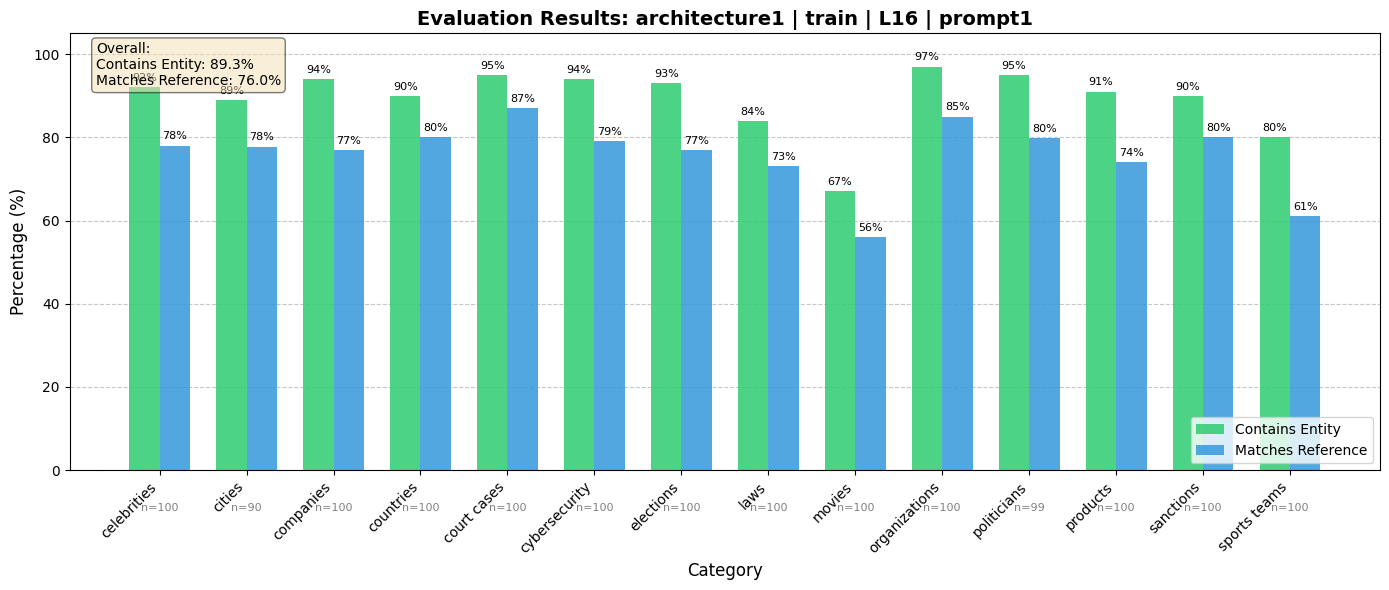


Plotting: architecture1 | eval | L16 | prompt1
Loaded 279 rows from results_v1/architecture1/eval_results_L16_prompt1_evaluated.csv
Plot saved to: results_v1/evaluation_plots/architecture1_eval_L16_prompt1_evaluation.png


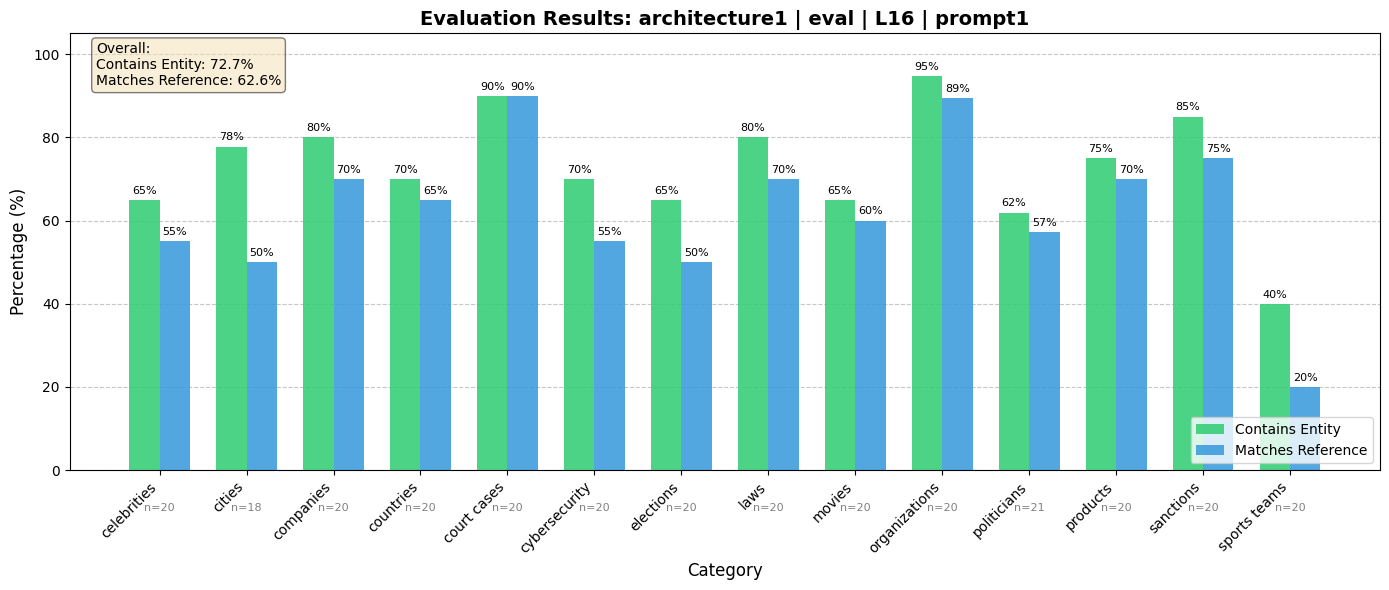


Plotting: architecture1 | test | L16 | prompt1
Loaded 154 rows from results_v1/architecture1/test_results_L16_prompt1_evaluated.csv
Plot saved to: results_v1/evaluation_plots/architecture1_test_L16_prompt1_evaluation.png


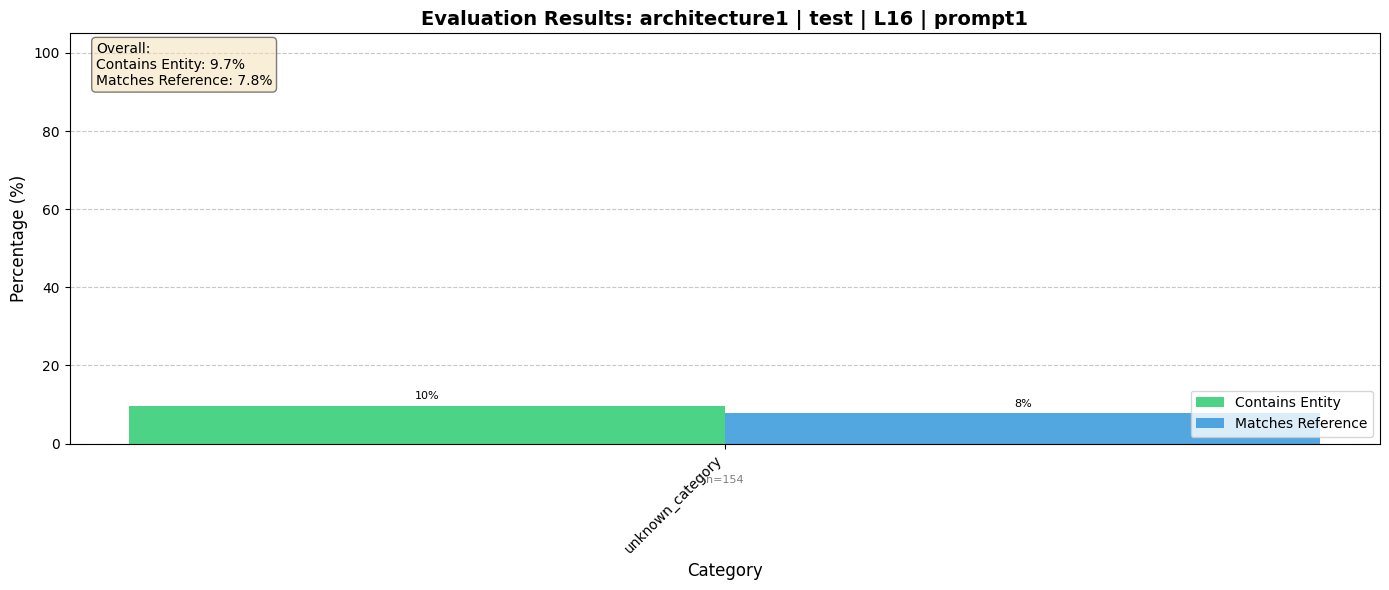


Plotting: architecture2 | train | L16 | prompt1
Loaded 1389 rows from results_v1/architecture2/train_results_L16_prompt1_evaluated.csv
Plot saved to: results_v1/evaluation_plots/architecture2_train_L16_prompt1_evaluation.png


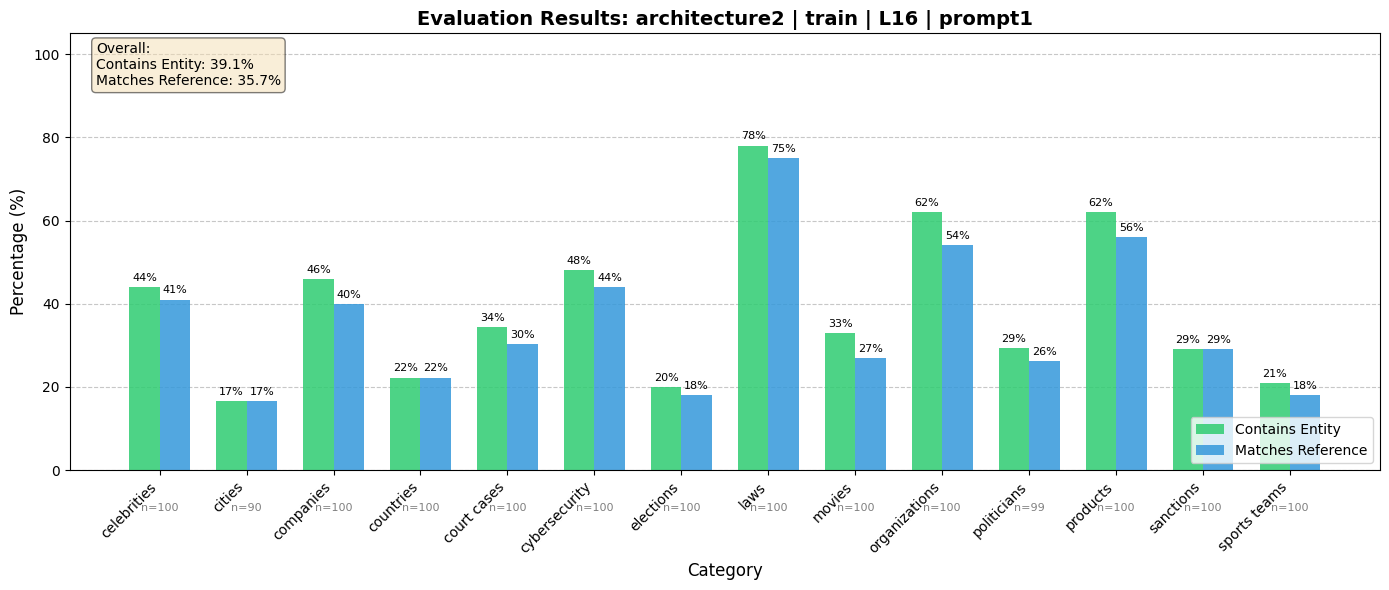


Plotting: architecture2 | eval | L16 | prompt1
Loaded 279 rows from results_v1/architecture2/eval_results_L16_prompt1_evaluated.csv
Plot saved to: results_v1/evaluation_plots/architecture2_eval_L16_prompt1_evaluation.png


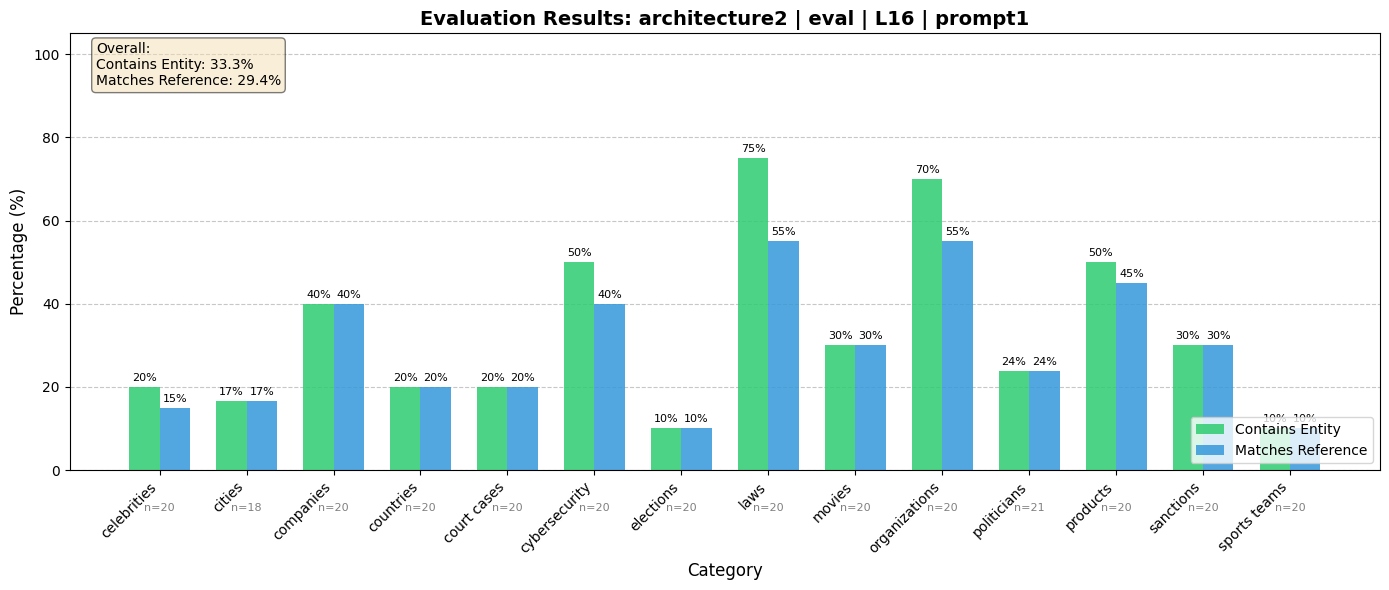


Plotting: architecture2 | test | L16 | prompt1
Loaded 154 rows from results_v1/architecture2/test_results_L16_prompt1_evaluated.csv
Plot saved to: results_v1/evaluation_plots/architecture2_test_L16_prompt1_evaluation.png


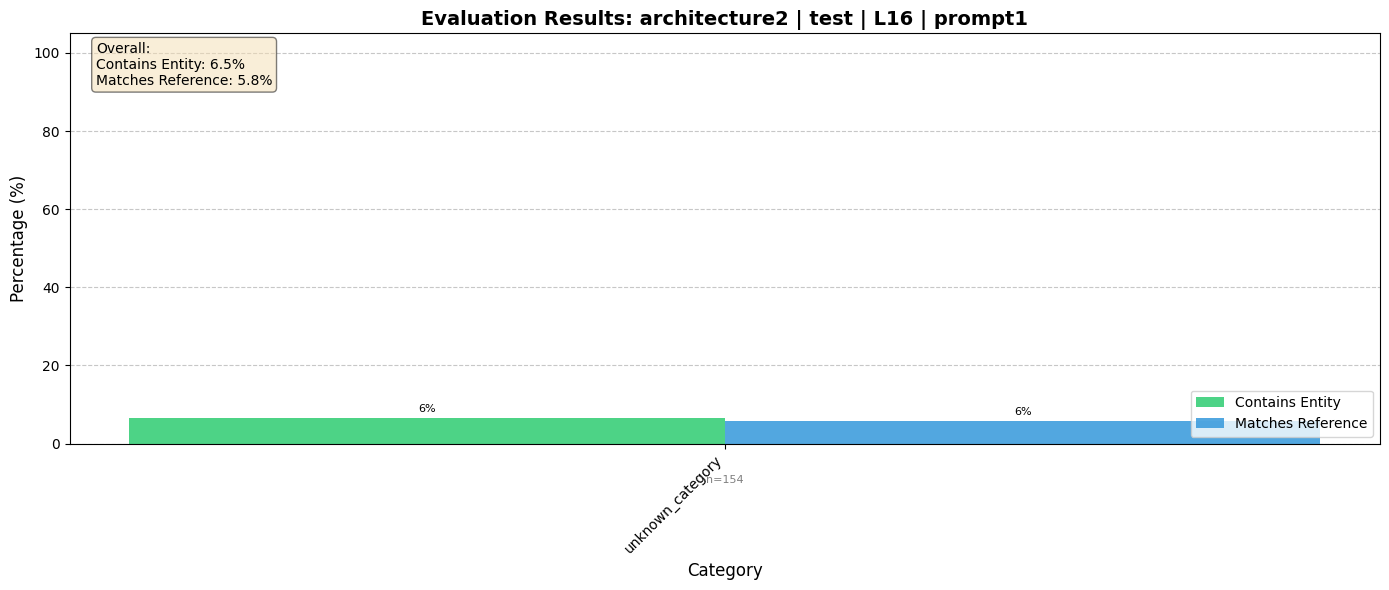


############################################################
# ARCHITECTURE COMPARISONS
############################################################

Architecture Comparison: train
Comparison plot saved to: results_v1/evaluation_plots/comparison_train_L16_prompt1.png


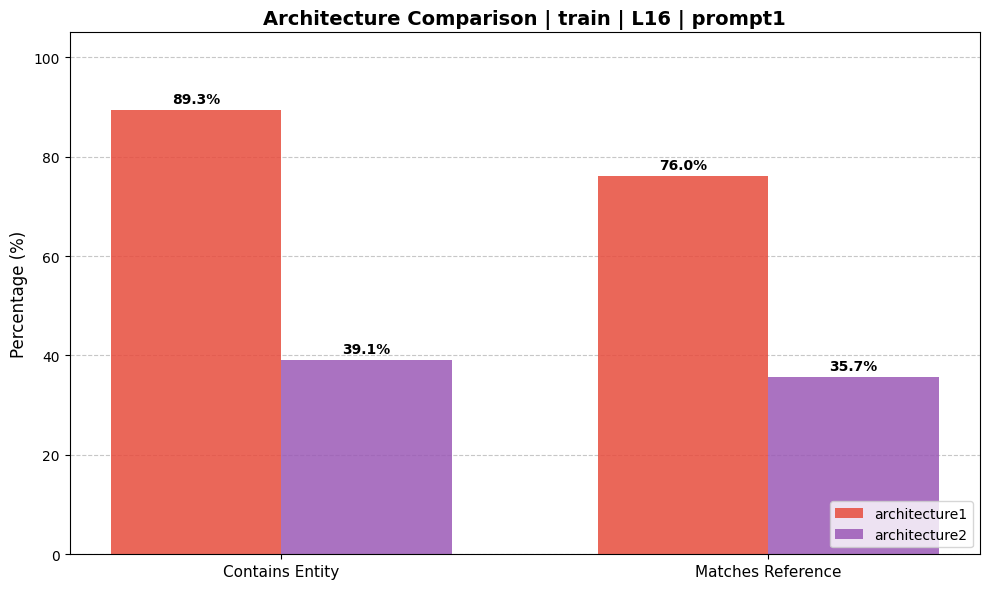


Architecture Comparison: eval
Comparison plot saved to: results_v1/evaluation_plots/comparison_eval_L16_prompt1.png


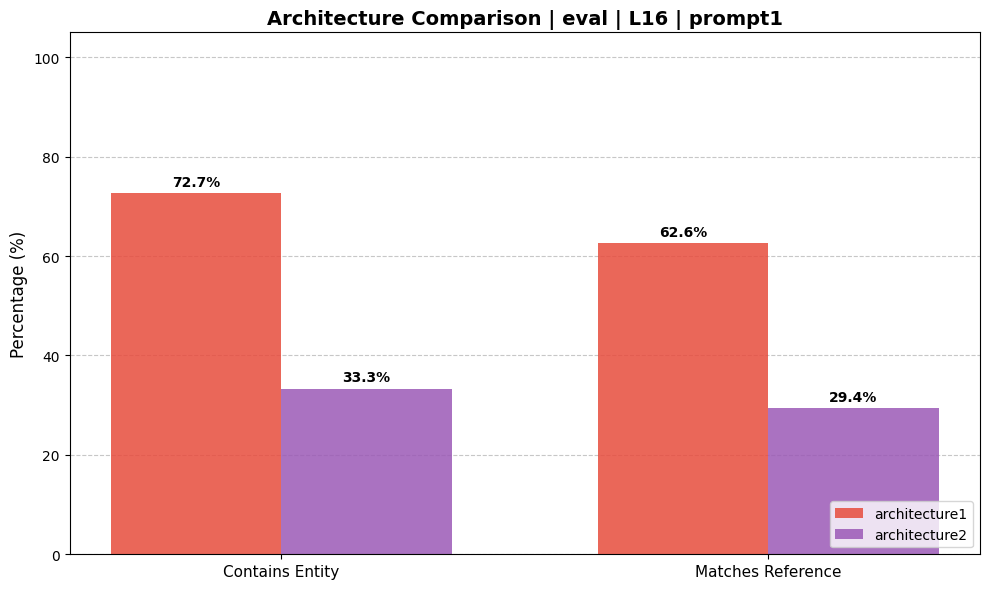


Architecture Comparison: test
Comparison plot saved to: results_v1/evaluation_plots/comparison_test_L16_prompt1.png


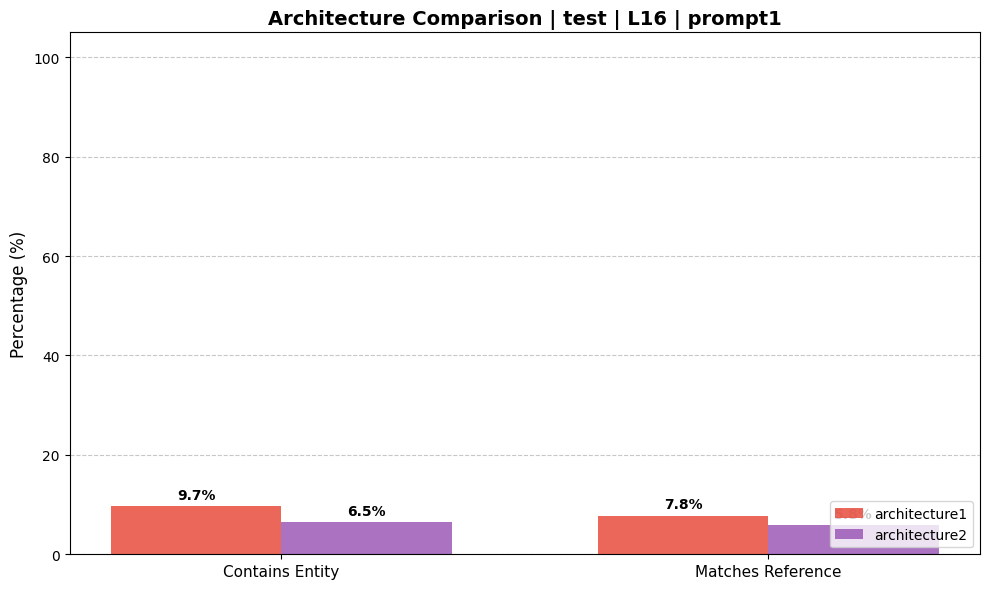

In [ ]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

all_metrics = run_all_visualizations()

# Generate architecture comparison plots
print("\n" + "#"*60)
print("# ARCHITECTURE COMPARISONS")
print("#"*60)
run_all_comparisons()

## Cell 14: Cosine Similarity on Activations before and after Adapter

This cell analyzes how much the adapter transforms the original activations.

Metrics computed:
1. Cosine Similarity: cos(x, x + adapter(x)) - measures directional change
2. Relative Magnitude: ||adapter(x)|| / ||x|| - measures strength of steering signal

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BASE_DIR = "results_v1"
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

# Analysis settings
LAYER = 16
EXTRACTION_POS = "resid_post"
NORMALIZE_VECTORS = True
USE_LOWERCASE = True

# Architectures to analyze
ARCHITECTURES = [1, 2]

# Hidden dimensions for each architecture (must match training config)
ARCHITECTURE_CONFIGS = {
    1: {"hidden_dim": 4096, "dropout": 0.0},
    2: {"hidden_dim": 1024, "dropout": 0.5},
}

# Model's hidden dimension (Llama-3.1-8B = 4096)
INPUT_DIM = 4096

# Output directory for plots
PLOTS_OUTPUT_DIR = os.path.join(BASE_DIR, "activation_analysis_plots")

# ============================================================================
# ADAPTER ARCHITECTURES (must match training)
# ============================================================================

class InjectionAdapterV1(nn.Module):
    """Architecture 1: Simple 2-layer MLP (input -> hidden -> input)"""
    def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float = 0.0):
        super().__init__()
        # FC -> ReLU -> Dropout -> FC
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        return self.model(x)


class InjectionAdapterV2(nn.Module):
    """Architecture 2: Deeper MLP with bottleneck (input -> hidden -> hidden//2 -> hidden -> input)"""
    def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float = 0.0):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        return self.model(x)


def get_adapter_class(arch_id: int):
    """Factory function to get the correct adapter class based on architecture ID."""
    if arch_id == 1:
        return InjectionAdapterV1
    elif arch_id == 2:
        return InjectionAdapterV2
    else:
        raise ValueError(f"Unknown architecture ID: {arch_id}. Supported: 1, 2")


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_safe_model_name(model_name: str) -> str:
    return model_name.replace("/", "_")


def load_concept_vectors(base_dir: str, model_name: str, layer: int,
                         pos: str, normalize: bool, lowercase: bool) -> dict:
    """Load cached concept vectors (train mode only)."""
    norm_tag = "norm" if normalize else "raw"
    case_tag = "lower" if lowercase else "orig"
    safe_model = get_safe_model_name(model_name)

    filename = f"train_concepts_{safe_model}_L{layer}_{pos}_{norm_tag}_{case_tag}.pt"
    filepath = os.path.join(base_dir, "learning_cache", filename)

    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None

    print(f"Loading concept vectors from: {filepath}")
    data = torch.load(filepath, map_location="cpu")
    return data["vectors"]


def load_adapter(base_dir: str, model_name: str, layer: int, arch_id: int,
                 input_dim: int, hidden_dim: int, dropout: float) -> nn.Module:
    """Load trained adapter weights with the correct architecture."""
    safe_model = get_safe_model_name(model_name)
    filename = f"adapter_{safe_model}_L{layer}_architecture{arch_id}_hollistic.pt"
    filepath = os.path.join(base_dir, "trained_adapters", filename)

    if not os.path.exists(filepath):
        print(f"Adapter not found: {filepath}")
        return None

    print(f"Loading adapter from: {filepath}")

    # Get the correct adapter class based on architecture ID
    AdapterClass = get_adapter_class(arch_id)
    adapter = AdapterClass(input_dim=input_dim, hidden_dim=hidden_dim, dropout_prob=dropout)
    adapter.load_state_dict(torch.load(filepath, map_location="cpu"))
    adapter.eval()
    return adapter


def get_adapted_activations_path(base_dir: str, model_name: str, layer: int,
                                   pos: str, normalize: bool, lowercase: bool, arch_id: int) -> str:
    """Get the path for adapted activations cache file."""
    norm_tag = "norm" if normalize else "raw"
    case_tag = "lower" if lowercase else "orig"
    safe_model = get_safe_model_name(model_name)

    # Same filename as original but with 'adapted_' prefix, in architecture-specific subdirectory
    filename = f"train_adapted_concepts_{safe_model}_L{layer}_{pos}_{norm_tag}_{case_tag}.pt"
    cache_dir = os.path.join(base_dir, "adapted_activations", f"architecture{arch_id}")
    os.makedirs(cache_dir, exist_ok=True)
    return os.path.join(cache_dir, filename)


def load_adapted_activations(base_dir: str, model_name: str, layer: int,
                              pos: str, normalize: bool, lowercase: bool, arch_id: int) -> dict:
    """Load cached adapted activations if they exist."""
    filepath = get_adapted_activations_path(base_dir, model_name, layer, pos, normalize, lowercase, arch_id)

    if os.path.exists(filepath):
        print(f"Loading cached adapted activations from: {filepath}")
        data = torch.load(filepath, map_location="cpu")
        return data["vectors"]
    return None


def save_adapted_activations(adapted_vecs: dict, base_dir: str, model_name: str, layer: int,
                              pos: str, normalize: bool, lowercase: bool, arch_id: int):
    """Save adapted activations to cache."""
    filepath = get_adapted_activations_path(base_dir, model_name, layer, pos, normalize, lowercase, arch_id)
    print(f"Saving adapted activations to: {filepath}")
    torch.save({"vectors": adapted_vecs}, filepath)


def load_entity_categories(base_dir: str) -> dict:
    """Load entity-to-category mapping from the QA CSV."""
    csv_path = os.path.join(base_dir, "Entities_QA.csv")
    if not os.path.exists(csv_path):
        print(f"CSV not found: {csv_path}")
        return {}

    df = pd.read_csv(csv_path)
    mapping = {}
    for _, row in df.iterrows():
        word = str(row['Entity']).lower()
        category = str(row['Category']).lower()
        mapping[word] = category

    print(f"Loaded {len(mapping)} entity-category mappings")
    return mapping


# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def compute_activation_metrics(concept_vecs: dict,
                                adapter: nn.Module,
                                entity_categories: dict,
                                arch_id: int,
                                use_cache: bool = False) -> pd.DataFrame:
    """
    Compute cosine similarity and relative magnitude for each entity.

    Uses cached adapted activations if available, otherwise computes and saves them.

    Returns DataFrame with columns: entity, category, cosine_sim, relative_mag
    """
    # Try to load cached adapted activations
    adapted_vecs = None
    if use_cache:
        adapted_vecs = load_adapted_activations(
            BASE_DIR, MODEL_NAME, LAYER, EXTRACTION_POS,
            NORMALIZE_VECTORS, USE_LOWERCASE, arch_id
        )

    # If not cached, compute them
    if adapted_vecs is None:
        print("Computing adapted activations...")
        adapted_vecs = {}

        with torch.no_grad():
            for entity_key, x in tqdm(concept_vecs.items(), desc="Applying adapter"):
                # x shape: [1, hidden_dim] or [hidden_dim]
                if x.dim() == 1:
                    x = x.unsqueeze(0)  # [1, H]

                # Add batch dim for adapter: [1, 1, H]
                x_input = x.unsqueeze(0)

                # Get adapter output
                adapter_output_vec = adapter(x_input)  # [1, 1, H]
                adapter_output_vec = adapter_output_vec.squeeze(0)  # [1, H]

                # Store adapter output directly as the adapted vector
                adapted_vecs[entity_key] = adapter_output_vec

        # Save for future use
        if use_cache:
            save_adapted_activations(
                adapted_vecs, BASE_DIR, MODEL_NAME, LAYER,
                EXTRACTION_POS, NORMALIZE_VECTORS, USE_LOWERCASE, arch_id
            )
    else:
        print(f"Using cached adapted activations ({len(adapted_vecs)} entities)")

    # Now compute metrics
    results = []

    for entity_key in concept_vecs.keys():
        x = concept_vecs[entity_key]
        adapter_output = adapted_vecs[entity_key] # This is now the actual output of the adapter

        # Ensure correct shape
        if x.dim() == 1:
            x = x.unsqueeze(0)
        if adapter_output.dim() == 1:
            adapter_output = adapter_output.unsqueeze(0)

        # Flatten for calculations
        x_flat = x.flatten()
        adapter_output_flat = adapter_output.flatten()

        # Cosine similarity: cos(x, adapter_output(x))
        # This measures the directional alignment between the original concept vector and the injected vector
        cos_sim = F.cosine_similarity(x_flat.unsqueeze(0), adapter_output_flat.unsqueeze(0)).item()

        # Relative magnitude: ||adapter_output(x)|| / ||x||
        # This measures the strength of the injected signal relative to the original concept
        x_norm = torch.norm(x_flat).item()
        adapter_output_norm = torch.norm(adapter_output_flat).item()
        rel_mag = adapter_output_norm / x_norm if x_norm > 0 else 0.0

        # Get category
        category = entity_categories.get(entity_key, "unknown")

        results.append({
            "entity": entity_key,
            "category": category,
            "cosine_sim": cos_sim,
            "relative_mag": rel_mag,
            "x_norm": x_norm,
            "adapter_norm": adapter_output_norm # Renamed for clarity
        })

    return pd.DataFrame(results)


# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def plot_metrics_by_category(df: pd.DataFrame, arch_id: int,
                              save_plot: bool = True, show_plot: bool = True):
    """
    Plot bar charts of cosine similarity and relative magnitude per category.
    """
    # Aggregate by category
    category_stats = df.groupby('category').agg(
        cosine_sim_mean=('cosine_sim', 'mean'),
        cosine_sim_std=('cosine_sim', 'std'),
        relative_mag_mean=('relative_mag', 'mean'),
        relative_mag_std=('relative_mag', 'std'),
        count=('entity', 'size')
    ).reset_index().sort_values('category')

    categories = category_stats['category'].tolist()
    x = np.arange(len(categories))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Cosine Similarity ---
    ax1 = axes[0]
    bars1 = ax1.bar(x, category_stats['cosine_sim_mean'], width,
                    yerr=category_stats['cosine_sim_std'], capsize=3,
                    color='#3498db', alpha=0.85)

    ax1.set_xlabel('Category', fontsize=12)
    ax1.set_ylabel('Cosine Similarity', fontsize=12)
    ax1.set_title(f'Cosine Similarity: x vs adapter_out(x)\nArchitecture {arch_id}', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
    ax1.set_ylim(0, 1.05)
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='No change (cos=1)')
    ax1.legend(loc='lower right')
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Relative Magnitude ---
    ax2 = axes[1]
    bars2 = ax2.bar(x, category_stats['relative_mag_mean'], width,
                    yerr=category_stats['relative_mag_std'], capsize=3,
                    color='#e74c3c', alpha=0.85)

    ax2.set_xlabel('Category', fontsize=12)
    ax2.set_ylabel('Relative Magnitude (||adapter_out(x)|| / ||x||)', fontsize=12)
    ax2.set_title(f'Steering Signal Strength\nArchitecture {arch_id}', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
    ax2.yaxis.grid(True, linestyle='--', alpha=0.7)

    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

    # Add sample counts below category names
    for i, count in enumerate(category_stats['count']):
        ax1.annotate(f'n={count}', xy=(x[i], -0.08), ha='center', fontsize=8, color='gray',
                     xycoords=('data', 'axes fraction'))

    plt.tight_layout()

    if save_plot:
        os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
        plot_path = os.path.join(PLOTS_OUTPUT_DIR, f"arch{arch_id}_metrics_by_category.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    return category_stats


def plot_distribution(df: pd.DataFrame, arch_id: int,
                      save_plot: bool = True, show_plot: bool = True):
    """
    Plot distribution (violin plots) of metrics per category.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Sort categories for consistent ordering
    category_order = sorted(df['category'].unique())

    # --- Cosine Similarity Distribution ---
    ax1 = axes[0]
    sns.violinplot(data=df, x='category', y='cosine_sim', order=category_order,
                   ax=ax1, palette='Blues', inner='box')
    ax1.set_xlabel('Category', fontsize=12)
    ax1.set_ylabel('Cosine Similarity (x vs adapter_out(x))', fontsize=12)
    ax1.set_title(f'Cosine Similarity Distribution\nArchitecture {arch_id}', fontsize=13, fontweight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='No change')
    ax1.set_ylim(None, 1.05)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

    # --- Relative Magnitude Distribution ---
    ax2 = axes[1]
    sns.violinplot(data=df, x='category', y='relative_mag', order=category_order,
                   ax=ax2, palette='Reds', inner='box')
    ax2.set_xlabel('Category', fontsize=12)
    ax2.set_ylabel('Relative Magnitude (||adapter_out(x)|| / ||x||)', fontsize=12)
    ax2.set_title(f'Steering Signal Magnitude Distribution\nArchitecture {arch_id}', fontsize=13, fontweight='bold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.yaxis.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()

    if save_plot:
        os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
        plot_path = os.path.join(PLOTS_OUTPUT_DIR, f"arch{arch_id}_distribution.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()


def plot_architecture_comparison(results: dict, save_plot: bool = True, show_plot: bool = True):
    """
    Compare metrics across architectures.
    """
    if len(results) < 2:
        print("Need at least 2 architectures for comparison")
        return

    # Prepare data
    arch_ids = sorted(results.keys())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Aggregate overall stats per architecture
    stats = []
    for arch_id in arch_ids:
        df = results[arch_id]
        stats.append({
            'arch': f'Architecture {arch_id}',
            'cosine_sim': df['cosine_sim'].mean(),
            'cosine_sim_std': df['cosine_sim'].std(),
            'relative_mag': df['relative_mag'].mean(),
            'relative_mag_std': df['relative_mag'].std()
        })
    stats_df = pd.DataFrame(stats)

    x = np.arange(len(arch_ids))
    width = 0.5
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

    # Cosine similarity
    ax1 = axes[0]
    bars1 = ax1.bar(x, stats_df['cosine_sim'], width, yerr=stats_df['cosine_sim_std'],
                    capsize=5, color=[colors[i % len(colors)] for i in range(len(arch_ids))], alpha=0.85)
    ax1.set_ylabel('Cosine Similarity (x vs adapter_out(x))', fontsize=12)
    ax1.set_title('Overall Cosine Similarity by Architecture', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(stats_df['arch'])
    ax1.set_ylim(0, 1.05)
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

    for bar in bars1:
        ax1.annotate(f'{bar.get_height():.4f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Relative magnitude
    ax2 = axes[1]
    bars2 = ax2.bar(x, stats_df['relative_mag'], width, yerr=stats_df['relative_mag_std'],
                    capsize=5, color=[colors[i % len(colors)] for i in range(len(arch_ids))], alpha=0.85)
    ax2.set_ylabel('Relative Magnitude (||adapter_out(x)|| / ||x||)', fontsize=12)
    ax2.set_title('Overall Steering Strength by Architecture', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(stats_df['arch'])
    ax2.yaxis.grid(True, linestyle='--', alpha=0.7)

    for bar in bars2:
        ax2.annotate(f'{bar.get_height():.4f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()

    if save_plot:
        os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
        plot_path = os.path.join(PLOTS_OUTPUT_DIR, "architecture_comparison.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {plot_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_analysis():
    """Run full analysis for all architectures."""

    # Load entity-category mapping
    entity_categories = load_entity_categories(BASE_DIR)

    # Load concept vectors (same for all architectures)
    concept_vecs = load_concept_vectors(
        BASE_DIR, MODEL_NAME, LAYER,
        EXTRACTION_POS, NORMALIZE_VECTORS, USE_LOWERCASE
    )

    if concept_vecs is None:
        print("Failed to load concept vectors. Exiting.")
        return None

    print(f"Loaded {len(concept_vecs)} entity vectors")

    all_results = {}

    for arch_id in ARCHITECTURES:
        print(f"\n{'#'*60}")
        print(f"# ARCHITECTURE {arch_id}")
        print(f"{'#'*60}")

        arch_config = ARCHITECTURE_CONFIGS.get(arch_id, {"hidden_dim": 4096, "dropout": 0.0})

        # Load adapter
        adapter = load_adapter(
            BASE_DIR, MODEL_NAME, LAYER, arch_id,
            input_dim=INPUT_DIM,
            hidden_dim=arch_config["hidden_dim"],
            dropout=arch_config["dropout"]
        )

        if adapter is None:
            print(f"Skipping architecture {arch_id} - adapter not found")
            continue

        # Compute metrics
        print(f"\nComputing metrics...")
        df = compute_activation_metrics(concept_vecs, adapter, entity_categories, arch_id)
        all_results[arch_id] = df

        # Plot bar charts by category
        print(f"\nGenerating bar plots...")
        plot_metrics_by_category(df, arch_id)

        # Plot distributions
        print(f"\nGenerating distribution plots...")
        plot_distribution(df, arch_id)

    # Architecture comparison
    if len(all_results) >= 2:
        print(f"\n{'#'*60}")
        print("# ARCHITECTURE COMPARISON")
        print(f"{'#'*60}")
        plot_architecture_comparison(all_results)

    # Print summary statistics
    print(f"\n{'='*60}")
    print("SUMMARY STATISTICS")
    print(f"{'='*60}")

    for arch_id, df in all_results.items():
        print(f"\nArchitecture {arch_id}:")
        print(f"  Cosine Similarity:  mean={df['cosine_sim'].mean():.4f}, std={df['cosine_sim'].std():.4f}, min={df['cosine_sim'].min():.4f}, max={df['cosine_sim'].max():.4f}")
        print(f"  Relative Magnitude: mean={df['relative_mag'].mean():.4f}, std={df['relative_mag'].std():.4f}, min={df['relative_mag'].min():.4f}, max={df['relative_mag'].max():.4f}")

    return all_results


Loaded 248 entity-category mappings
Loading concept vectors from: results_v1/learning_cache/train_concepts_meta-llama_Llama-3.1-8B-Instruct_L16_resid_post_norm_lower.pt
Loaded 248 entity vectors

############################################################
# ARCHITECTURE 1
############################################################
Loading adapter from: results_v1/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_L16_architecture1_hollistic.pt

Computing metrics...
Computing adapted activations...


Applying adapter:   0%|          | 0/248 [00:00<?, ?it/s]


Generating bar plots...
Saved: results_v1/activation_analysis_plots/arch1_metrics_by_category.png


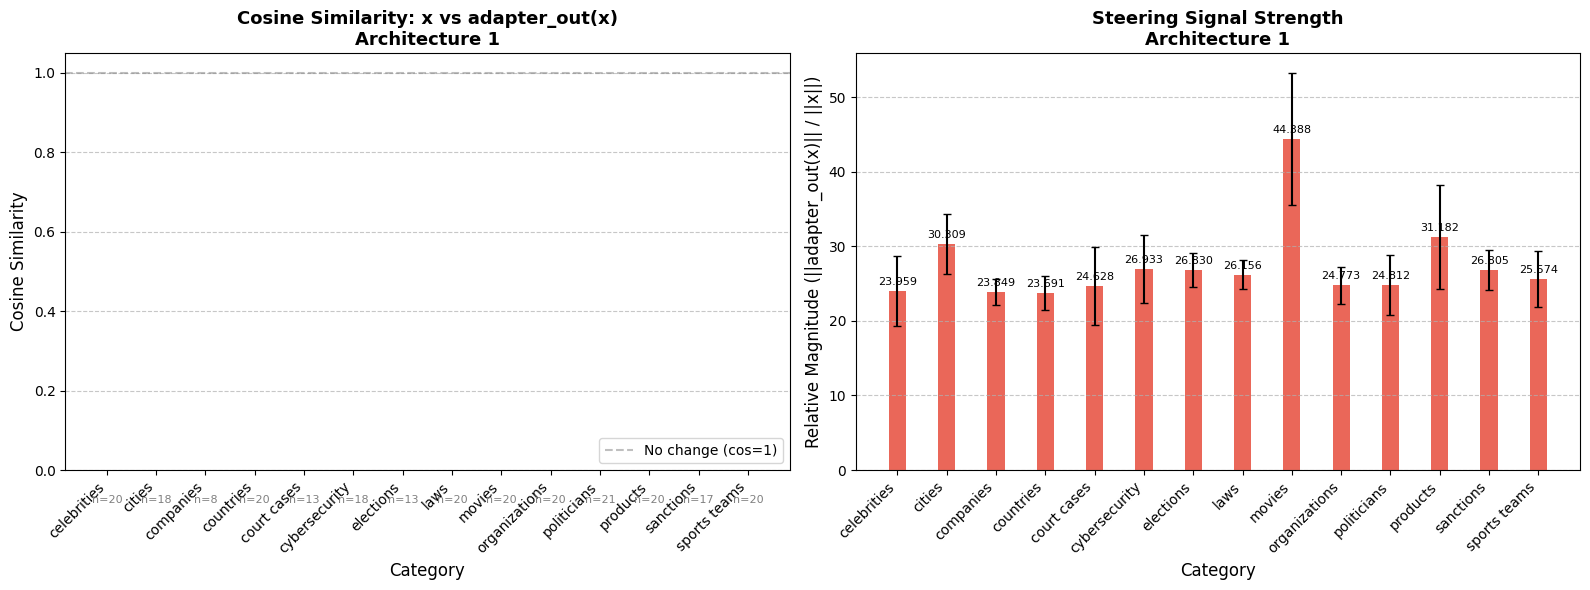


Generating distribution plots...


/tmp/ipython-input-3662381679.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='category', y='cosine_sim', order=category_order,
/tmp/ipython-input-3662381679.py:383: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3662381679.py:390: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='category', y='relative_mag', order=category_order,
/tmp/ipython-input-3662381679.py:395: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

Saved: results_v1/activation_analysis_plots/arch1_distribution.png


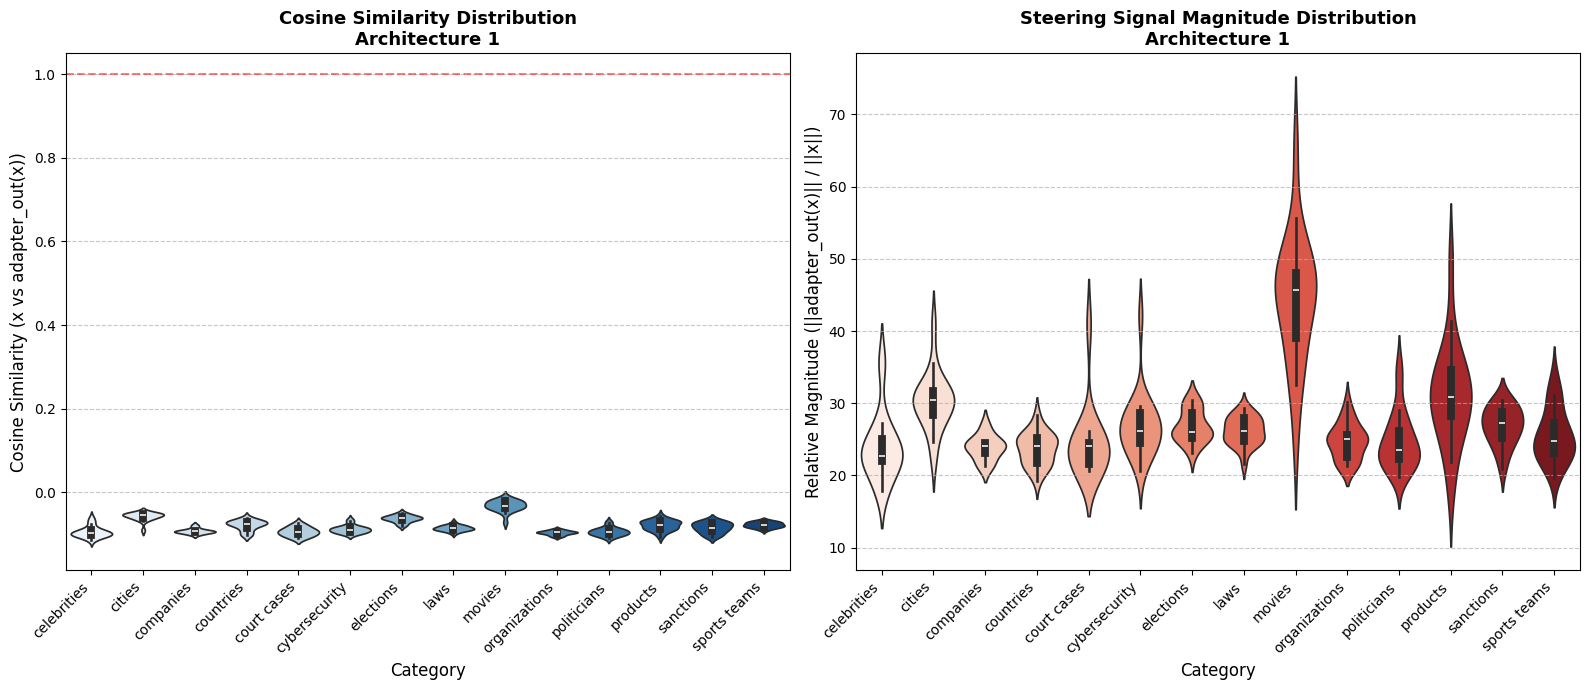


############################################################
# ARCHITECTURE 2
############################################################
Loading adapter from: results_v1/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_L16_architecture2_hollistic.pt

Computing metrics...
Computing adapted activations...


Applying adapter:   0%|          | 0/248 [00:00<?, ?it/s]


Generating bar plots...
Saved: results_v1/activation_analysis_plots/arch2_metrics_by_category.png


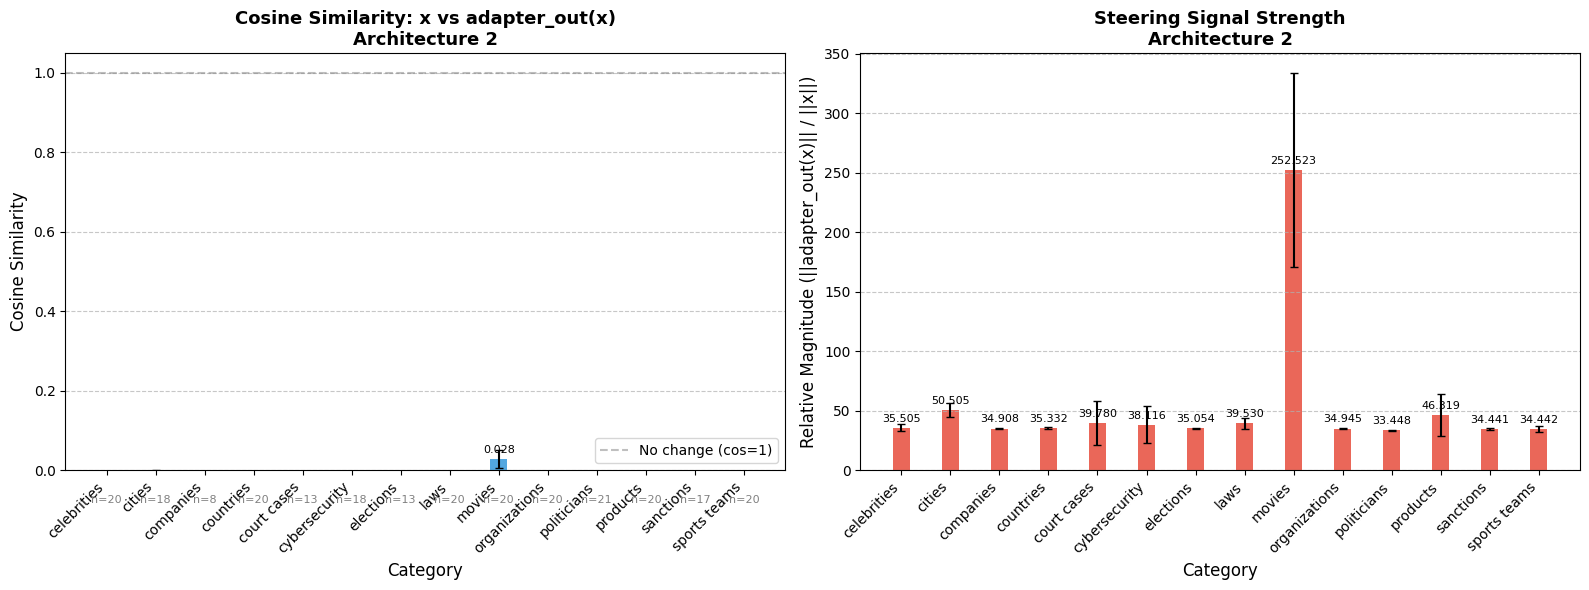


Generating distribution plots...


/tmp/ipython-input-3662381679.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='category', y='cosine_sim', order=category_order,
/tmp/ipython-input-3662381679.py:383: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3662381679.py:390: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='category', y='relative_mag', order=category_order,
/tmp/ipython-input-3662381679.py:395: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

Saved: results_v1/activation_analysis_plots/arch2_distribution.png


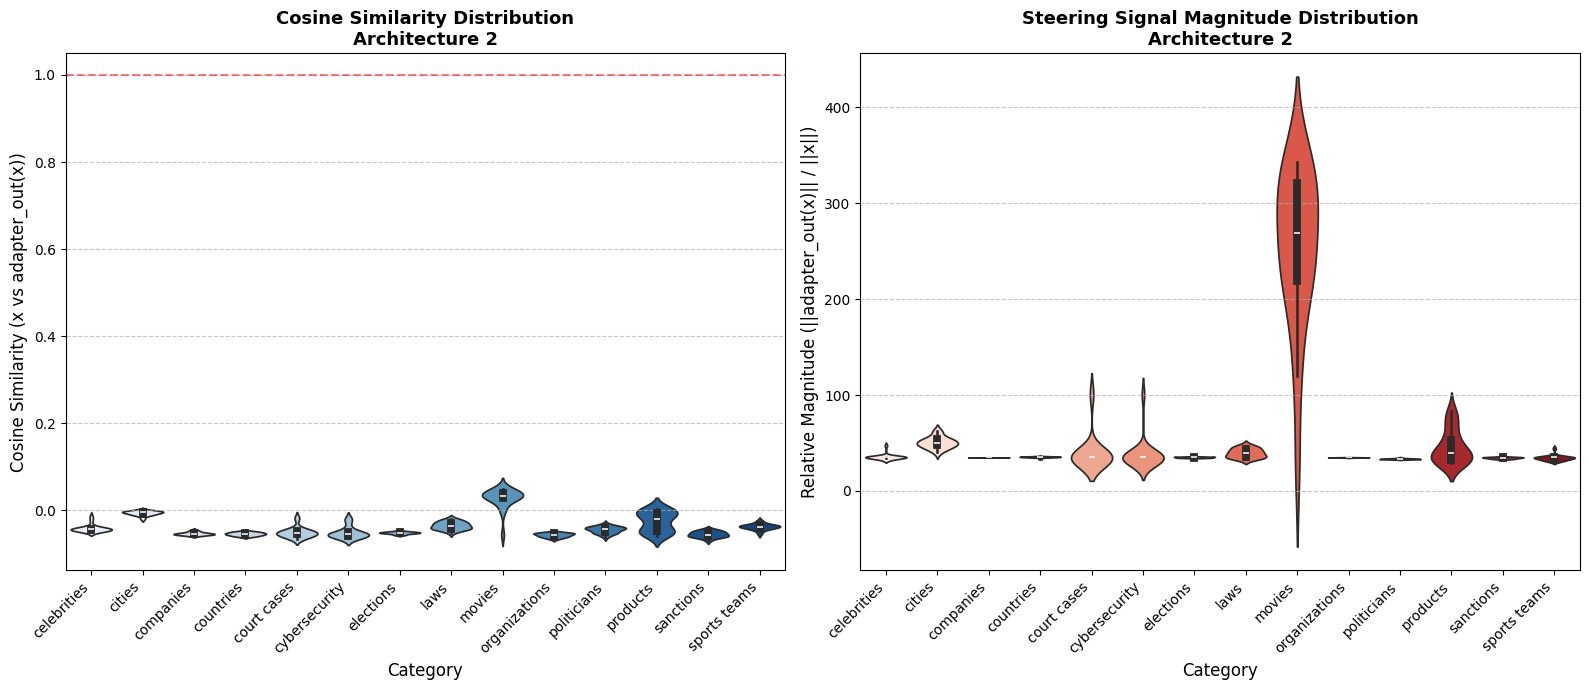


############################################################
# ARCHITECTURE COMPARISON
############################################################
Saved: results_v1/activation_analysis_plots/architecture_comparison.png


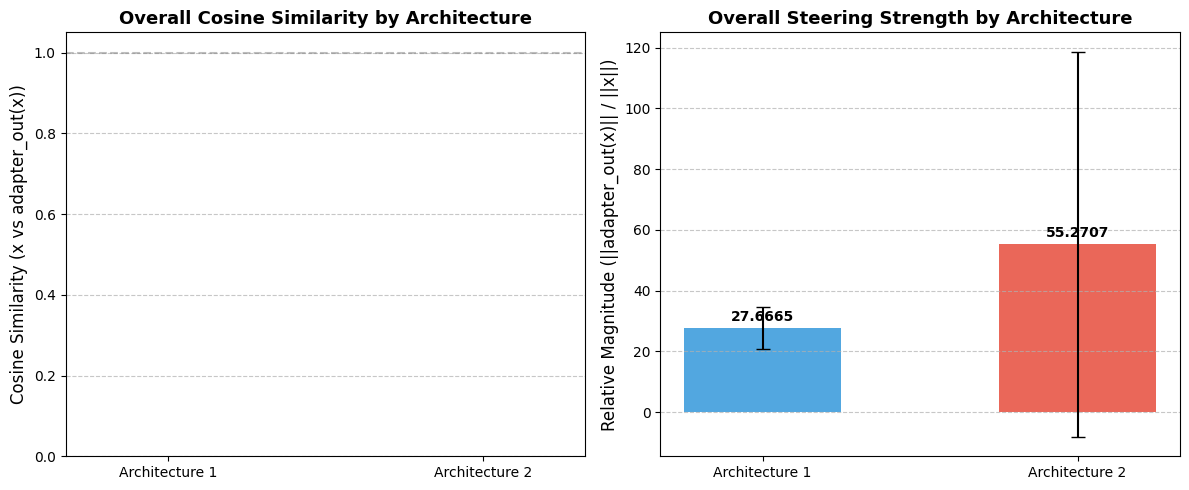


SUMMARY STATISTICS

Architecture 1:
  Cosine Similarity:  mean=-0.0789, std=0.0204, min=-0.1145, max=-0.0123
  Relative Magnitude: mean=27.6665, std=7.0140, min=17.8079, max=65.5279

Architecture 2:
  Cosine Similarity:  mean=-0.0367, std=0.0260, min=-0.0690, max=0.0490
  Relative Magnitude: mean=55.2707, std=63.4248, min=28.8980, max=342.7739


In [ ]:
# ============================================================================
# RUN
# ============================================================================

results = run_analysis()